## Access Radar Newcastle Velocity Hourly Averaged Realtime Non QC (Zarr)
This Jupyter notebook demonstrates how to access and plot radar_Newcastle_velocity_hourly_averaged_realtime_nonqc data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/e952bcee-79e7-4995-91ad-a7e6408d29ce).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/radar_Newcastle_velocity_hourly_averaged_realtime_nonqc.ipynb).


In [1]:
dataset_name = "radar_Newcastle_velocity_hourly_averaged_realtime_nonqc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv


✅ Virtual environment already exists, skipping creation.


Resolved 155 packages in 54ms
Checked 155 packages in 1ms


✅ Local version 0.3.11 is up to date (remote: 0.3.11)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4002: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 469 ms, sys: 38.9 ms, total: 508 ms
Wall time: 1.23 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	TIME = 38634 ;
	I = 69 ;
	J = 69 ;

variables:
	float64 GDOP(TIME, I, J) ;
		GDOP:comment = This angle is used to assess the impact of Geometric Dilution of Precision. If angle >= 150 or <= 30, then QC flag will not be lower than 4 (see abstract). ;
		GDOP:long_name = radar beam intersection angle ;
		GDOP:units = Degrees ;
		GDOP:valid_max = 180.0 ;
		GDOP:valid_min = 0.0 ;
	int32 I(I) ;
		I:long_name = row index (top most value is 1) ;
		I:units = 1 ;
	int32 J(J) ;
		J:long_name = column index (left most value is 1) ;
		J:units = 1 ;
	float64 LATITUDE(I, J) ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 datum ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE(I, J) ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, W

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2017-11-30 00:59:59.999996928'), Timestamp('2026-04-08 09:00:00'))

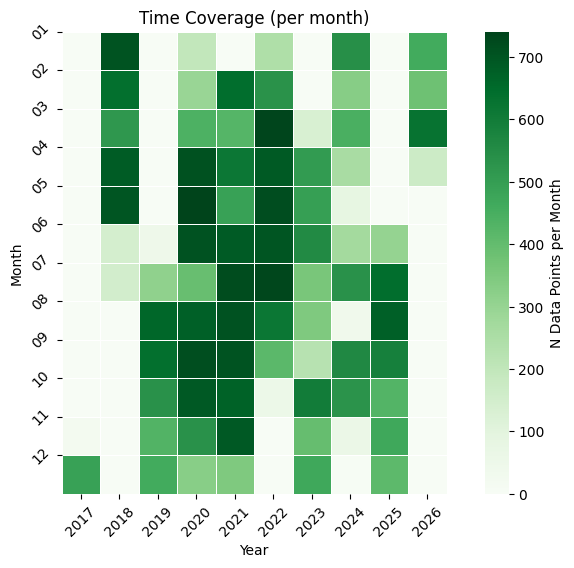

In [7]:
aodn_dataset.plot_time_coverage()

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:1144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the colorbar


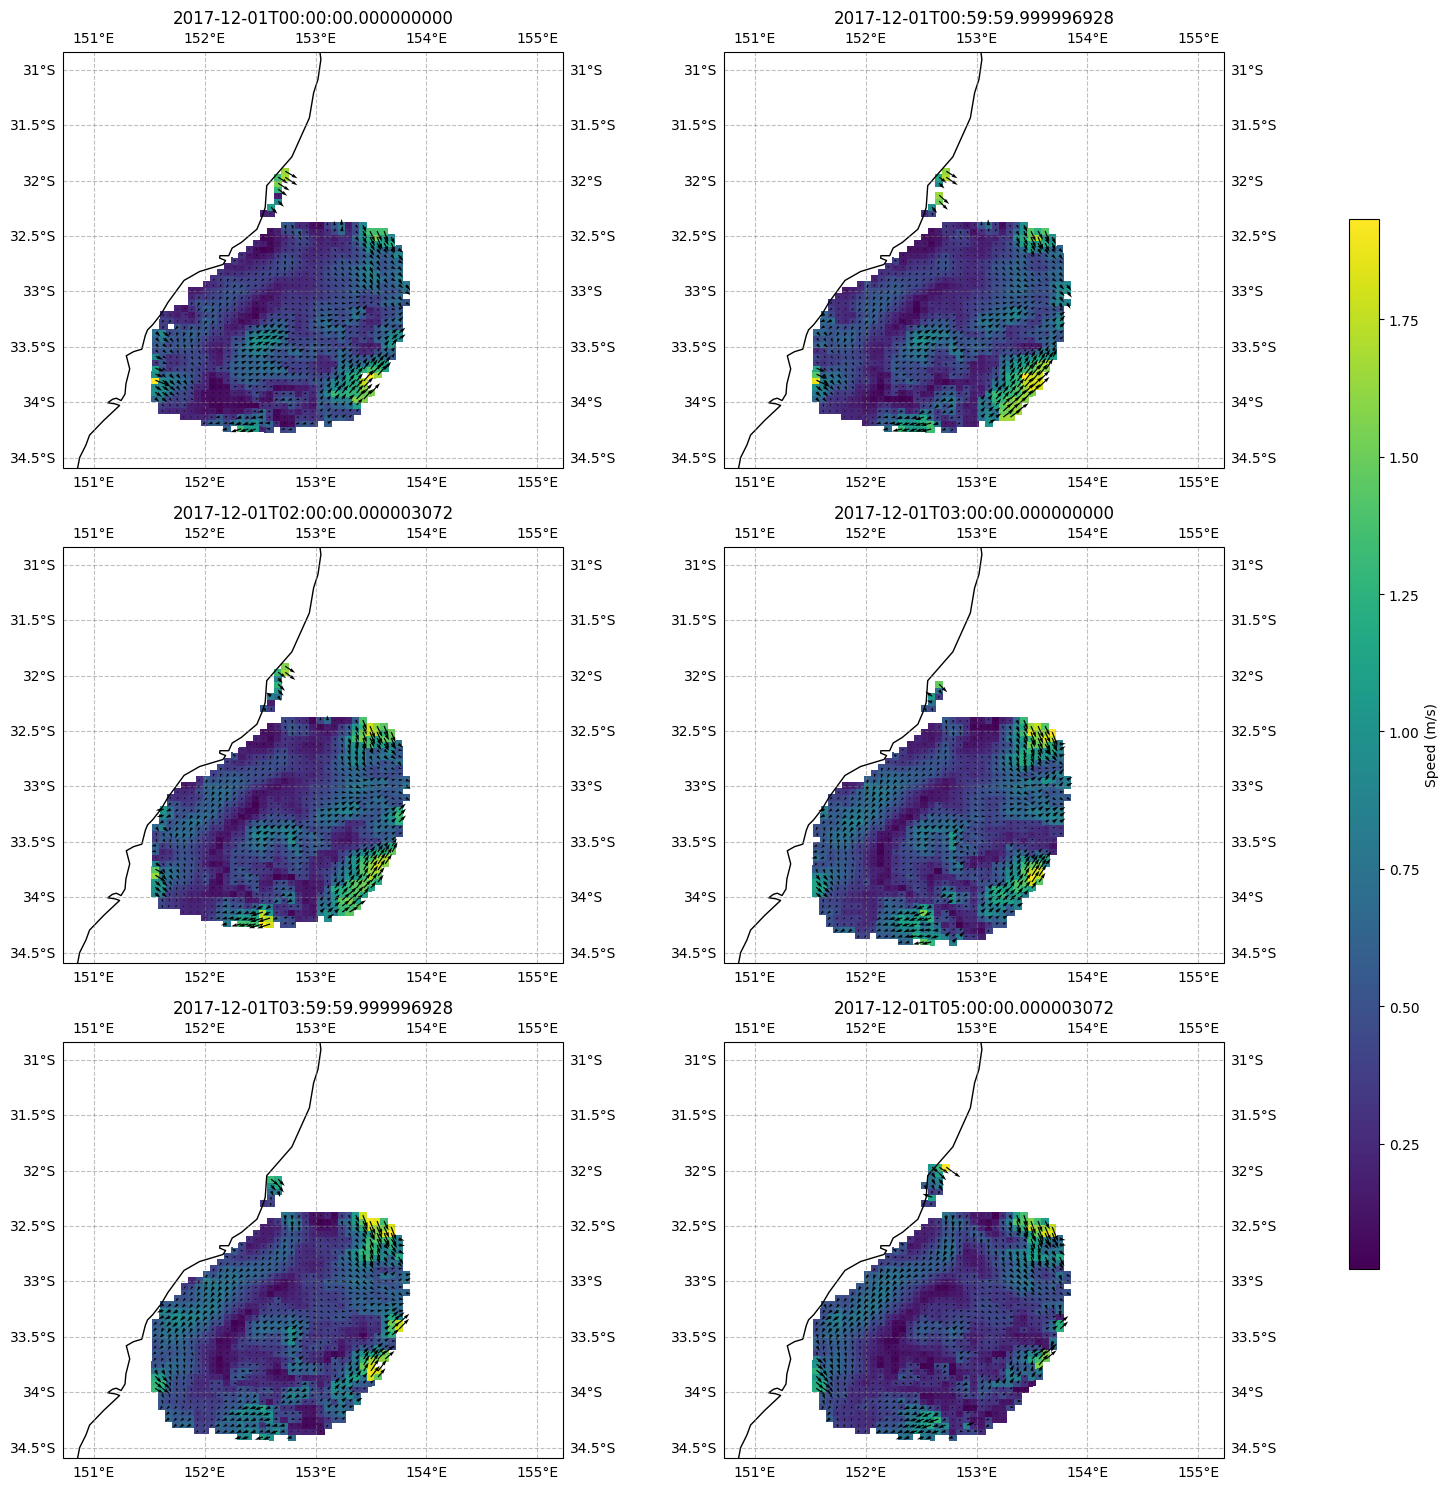

CPU times: user 2.34 s, sys: 1.87 s, total: 4.21 s
Wall time: 4.01 s


In [8]:
%%time
aodn_dataset.plot_radar_water_velocity_gridded(date_start='2017-12-01T00:00:00')

## Plot a gridded variable

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:1144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the colorbar


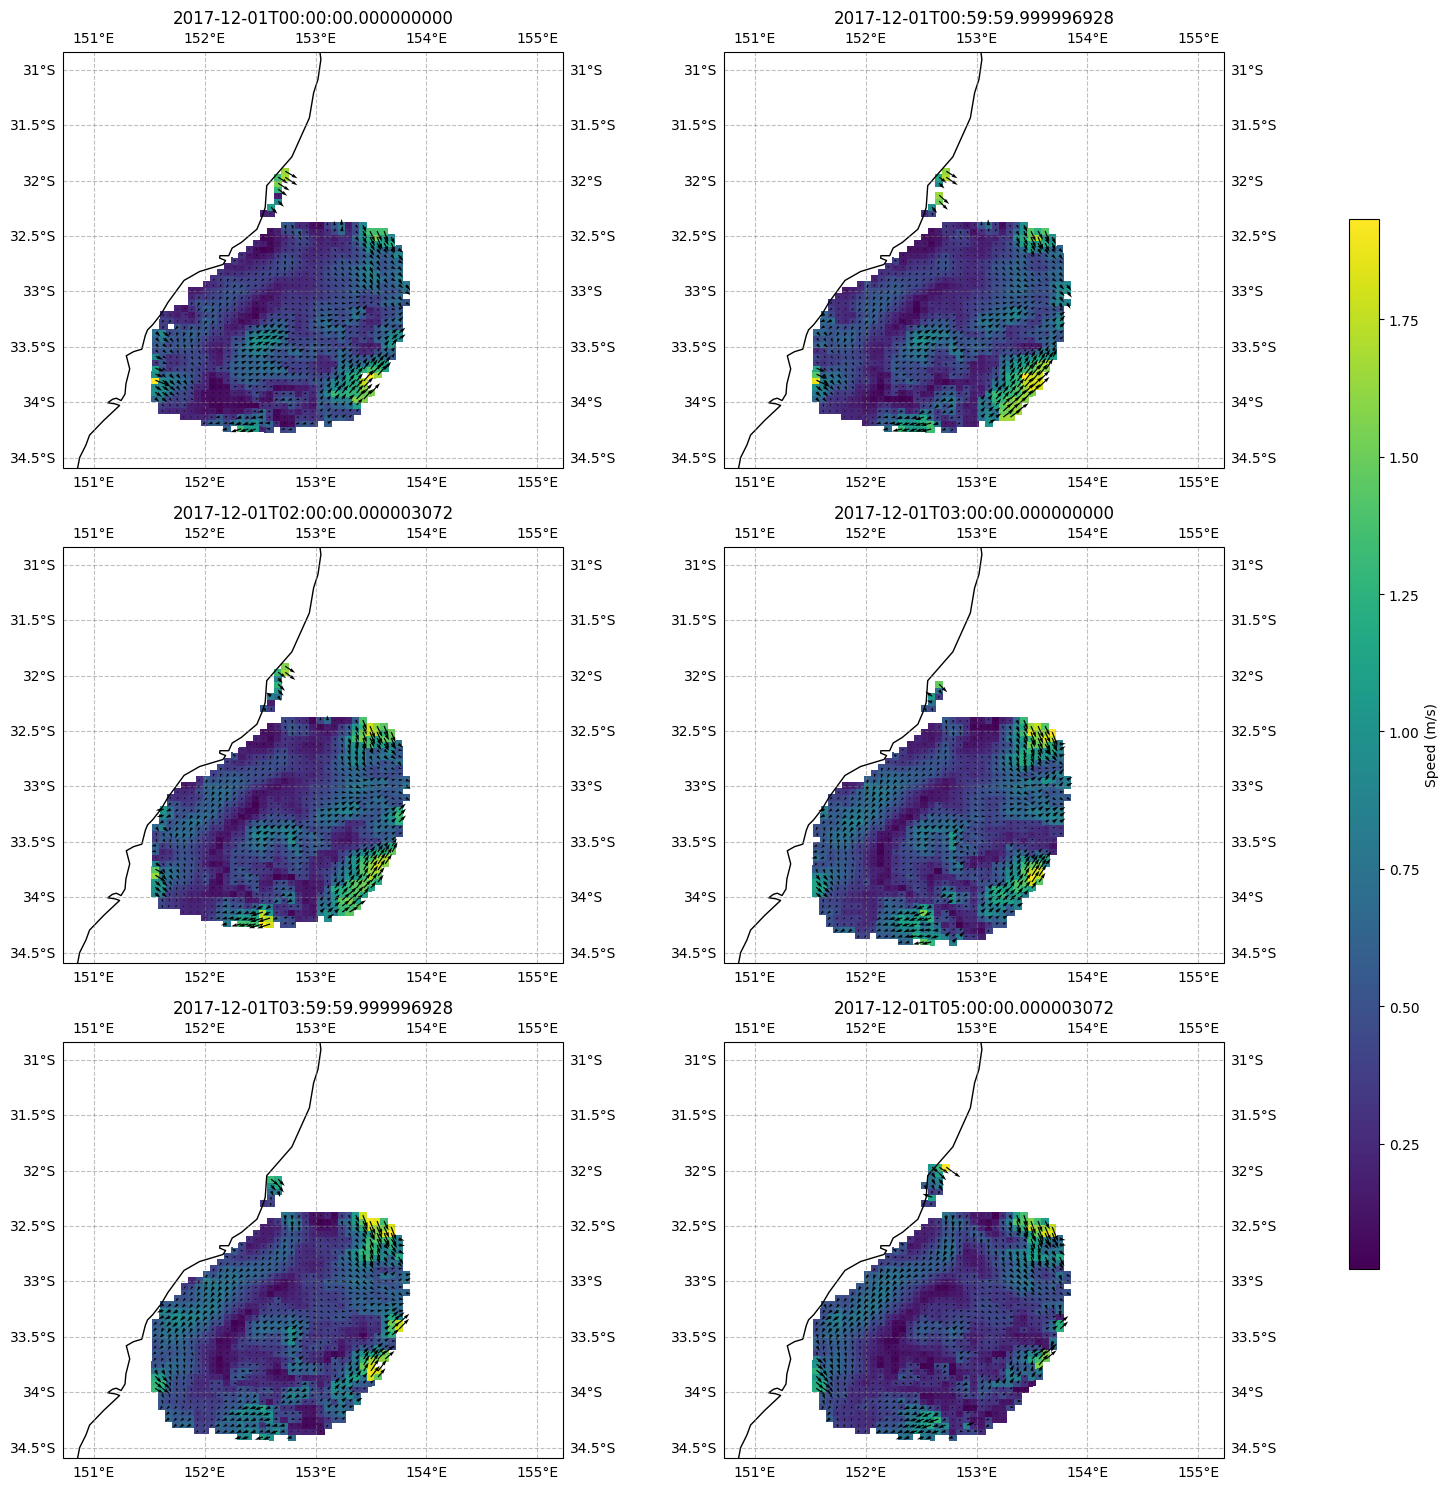

In [9]:
aodn_dataset.plot_radar_water_velocity_gridded(date_start='2017-12-01T00:00:00')

<Figure size 800x800 with 0 Axes>

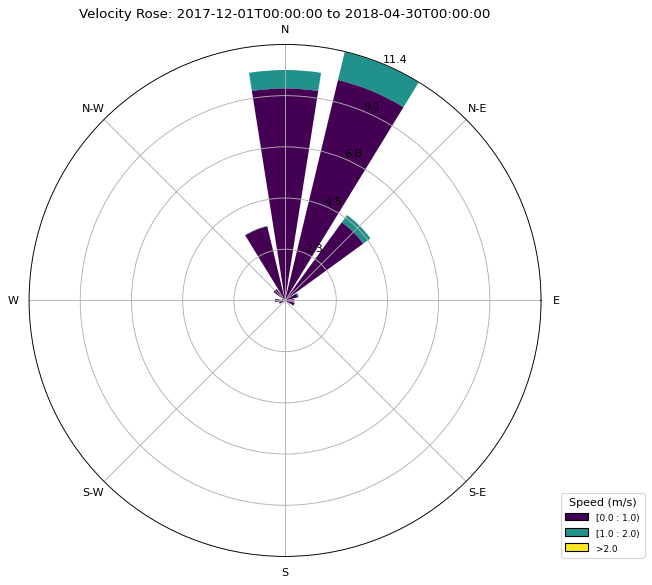

CPU times: user 756 ms, sys: 689 ms, total: 1.45 s
Wall time: 2.44 s


In [10]:
%%time
aodn_dataset.plot_radar_water_velocity_rose(date_start='2017-12-01T00:00:00', 
                                            date_end='2018-04-30T00:00:00')

Using highest-density point: -32.942°, 152.211°


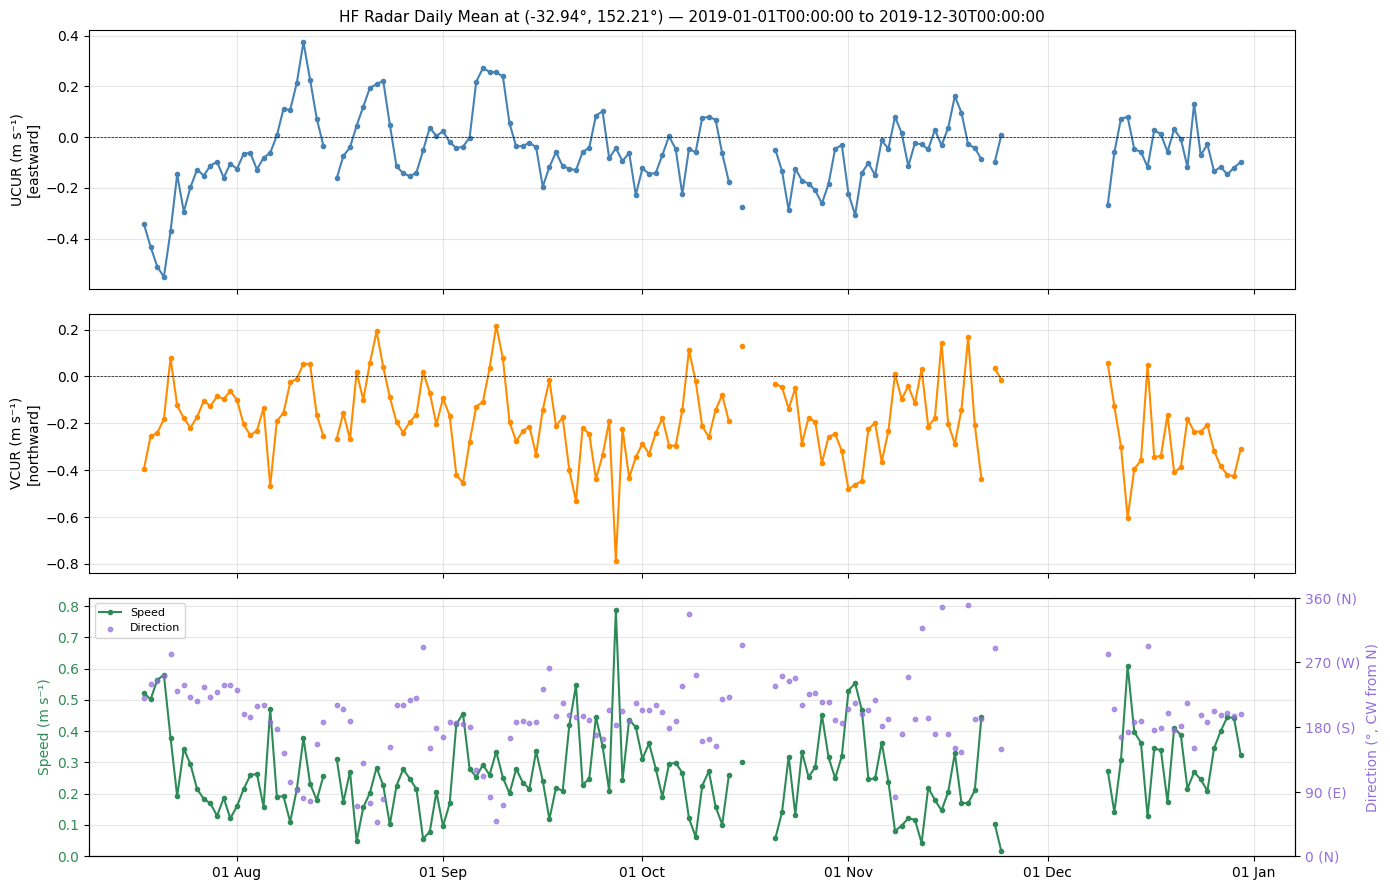

CPU times: user 708 ms, sys: 406 ms, total: 1.11 s
Wall time: 1.8 s


,u,v,speed,direction
TIME,,,,
2019-06-16,NaN,NaN,NaN,NaN
2019-06-17,NaN,NaN,NaN,NaN
2019-06-18,NaN,NaN,NaN,NaN
2019-06-19,NaN,NaN,NaN,NaN
2019-06-20,NaN,NaN,NaN,NaN
...,...,...,...,...
2019-12-26,-0.134872,-0.317696,0.345140,203.002673
2019-12-27,-0.116978,-0.383033,0.400498,196.982665
2019-12-28,-0.146838,-0.420346,0.445255,199.255641


In [11]:
%%time
aodn_dataset.plot_radar_water_velocity_timeseries(date_start='2019-01-01T00:00:00', 
                                            date_end='2019-12-30T00:00:00')